# 03 — RQ1: Lasso Regression for Stage-1 Turnaround Drivers

**Question:** Within Stage 1, which operational factors explain the largest share of observed turnaround time?

**Method:** Lasso regression (Tibshirani, 1996) with 5-fold cross-validation to select the regularization parameter λ. Bootstrap (1,000 resamples) for coefficient confidence intervals.

**Output:** `figures/fig4_lasso_coefs.png` — standardized coefficients at λ_min.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
FIG  = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

case = pd.read_csv(PROC / 'case_level_balanced_1000.csv')
print(case.shape)

(1000, 18)


## Feature engineering for the Lasso model

The outcome is `stage1_processing_time` (continuous, hours). Candidate predictors are the operational levers identified in the report:

In [2]:
features = ['completeness_flag', 'submission_channel',
            'product_complexity_index', 'requested_amount',
            'resource_workload', 'recent_exception_rate',
            'customer_segment', 'rework_indicator']
y = case['stage1_processing_time'].values
X = case[features].copy()
X['log_amount'] = np.log(X['requested_amount']); X = X.drop(columns=['requested_amount'])
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)
feature_names = X.columns.tolist()
print('predictor matrix:', X.shape)

predictor matrix: (1000, 11)


## Fit — LassoCV with 5-fold cross-validation

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

lasso = LassoCV(cv=KFold(n_splits=5, shuffle=True, random_state=42),
                random_state=42, max_iter=20_000).fit(X_train_s, y_train)
y_pred = lasso.predict(X_test_s)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'lambda_min = {lasso.alpha_:.4f}')
print(f'held-out R² = {r2:.3f}')
print(f'held-out RMSE = {rmse:.2f} hours')
n_nonzero = int((lasso.coef_ != 0).sum())
print(f'non-zero coefficients: {n_nonzero} / {len(feature_names)}')

lambda_min = 0.1495
held-out R² = 0.215
held-out RMSE = 14.72 hours
non-zero coefficients: 9 / 11


## Bootstrap 95% confidence intervals on the coefficients

In [4]:
rng = np.random.default_rng(42)
B = 1000
coef_boot = np.zeros((B, X_train_s.shape[1]))
for b in range(B):
    idx = rng.integers(0, X_train_s.shape[0], X_train_s.shape[0])
    m = Lasso(alpha=lasso.alpha_, max_iter=20_000)
    m.fit(X_train_s[idx], y_train[idx])
    coef_boot[b] = m.coef_
ci_low  = np.percentile(coef_boot,  2.5, axis=0)
ci_high = np.percentile(coef_boot, 97.5, axis=0)
summary = pd.DataFrame({
    'feature': feature_names,
    'coef':    lasso.coef_,
    'ci_low':  ci_low,
    'ci_high': ci_high,
}).sort_values('coef', key=lambda s: s.abs(), ascending=False)
summary

,feature,coef,ci_low,ci_high
0,completeness_flag,-6.925452,-8.318469,-5.481976
4,rework_indicator,3.219205,2.023455,4.646651
7,submission_channel_web,-3.148003,-4.589205,-1.645962
2,resource_workload,2.231414,1.020291,3.409136
3,recent_exception_rate,1.691916,0.531765,2.933331
1,product_complexity_index,1.617262,0.423306,2.973102
6,submission_channel_partner,-1.244991,-2.594248,0.000000
8,customer_segment_high-net-worth,-0.546933,-1.294909,0.000000
9,customer_segment_mass-affluent,-0.058133,-1.396663,1.033342
5,log_amount,0.000000,-1.651130,1.532071


## Figure 4 — Lasso-selected drivers of Stage-1 TAT

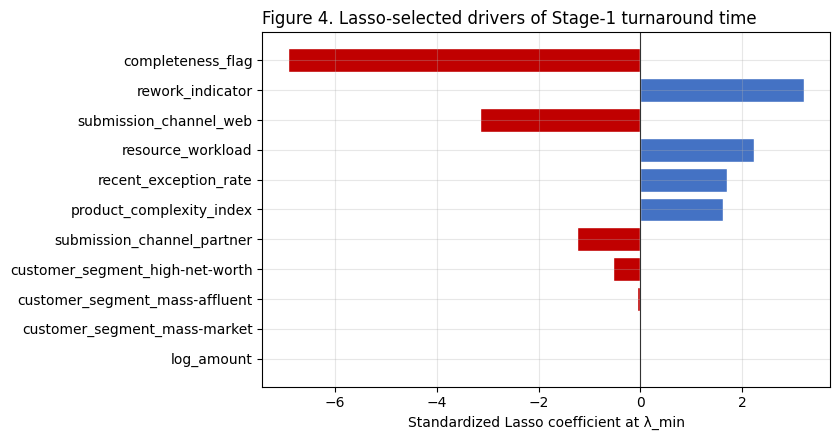

In [5]:
order = np.argsort(np.abs(lasso.coef_))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = ['#4472C4' if c >= 0 else '#C00000' for c in lasso.coef_[order]]
ax.barh(np.arange(len(feature_names)), lasso.coef_[order],
        color=colors, edgecolor='white')
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels(np.array(feature_names)[order])
ax.axvline(0, color='#333', lw=0.8)
ax.set_xlabel('Standardized Lasso coefficient at λ_min')
ax.set_title('Figure 4. Lasso-selected drivers of Stage-1 turnaround time',
             loc='left')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'fig4_lasso_coefs.png', dpi=160,
    bbox_inches='tight'); plt.show()

## Hypothesis test
H1₀: all coefficients are zero. H1₀ is **rejected** if any selected feature has a 95% bootstrap CI excluding zero.

In [6]:
summary['rejects_H0'] = (summary.ci_low > 0) | (summary.ci_high < 0)
print('Number of features rejecting H1_0 at 95%:',
      int(summary.rejects_H0.sum()))
print()
print(summary[summary.rejects_H0].to_string(index=False))

Number of features rejecting H1_0 at 95%: 6

                 feature      coef    ci_low   ci_high  rejects_H0
       completeness_flag -6.925452 -8.318469 -5.481976        True
        rework_indicator  3.219205  2.023455  4.646651        True
  submission_channel_web -3.148003 -4.589205 -1.645962        True
       resource_workload  2.231414  1.020291  3.409136        True
   recent_exception_rate  1.691916  0.531765  2.933331        True
product_complexity_index  1.617262  0.423306  2.973102        True
